# T004 · 基于配体的筛选：化合物相似性

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Andrea Morger, 2017-2020, [Volkamer 实验室](https://volkamerlab.org/)
- Franziska Fritz, CADD 研讨课 2018, Charité/FU Berlin
- Juan Carlos Roldan-Castillo, 2020, [Volkamer 实验室](https://volkamerlab.org/)
- Ingrid Vangone, 2022, [Volkamer 实验室](https://volkamerlab.org/)


__教程 T004__：本教程是 [第一篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x)中描述的 TeachOpenCADD 流程的一部分，该流程包含**教程 T001-T010**。


## 本教程的目标

在本教程中，我们将熟悉不同的分子编码方法（描述符、指纹）和比较方法（相似性度量）。此外，我们将以 EGFR 抑制剂吉非替尼（Gefitinib）为查询分子，对我们从 ChEMBL 数据库获取的 EGFR 化合物数据集进行虚拟筛选（相似性搜索）。


### _理论_ 部分内容

* 分子相似性
* 分子描述符
* 分子指纹
  * 基于子结构的指纹
  * MACCS 指纹
  * Morgan 指纹与圆形指纹
* 分子相似性度量
  * Tanimoto 系数
  * Dice 系数
* 虚拟筛选
  * 使用相似性搜索进行虚拟筛选
  * 富集图


### _实践_ 部分内容

* 导入并绘制分子
* 计算分子描述符
  * 1D 分子描述符：分子量
  * 2D 分子描述符：MACCS 指纹
  * 2D 分子描述符：Morgan 指纹
* 计算分子相似性
  * MACCS 指纹：Tanimoto 相似性 和 Dice 相似性
  * Morgan 指纹：Tanimoto 相似性 和 Dice 相似性
* 使用相似性搜索进行虚拟筛选
  * 将查询分子与数据集中的所有分子进行比较
  * 相似性值分布
  * 可视化最相似分子
  * 生成富集图
  * 计算富集因子


### 参考文献

* 有关"药物化学中的分子相似性"的综述（[<i>J. Med. Chem.</i> (2014), <b>57</b>, 3186-3204](https://pubmed.ncbi.nlm.nih.gov/24151987)）
* [Morgan 指纹](http://www.rdkit.org/docs/GettingStartedInPython.html#morgan-fingerprints-circular-fingerprints) 通过 `rdkit`
* MACCS 密钥的说明，请参阅 `rdkit` 文档：[Getting Started with the RDKit (ESP.cr)](https://www.rdkit.org/docs/GettingStartedInPython.html#maccs-gobbi-pharmacophore-fingerprint) 和 [RDKit 学习材料](http://rdkit.org/docs/Cookbook.html#fingerchk)
* 富集图：[J. Chem. Inf. Comput. Sci. 2001, 41 (6), 1593-1604](https://pubs.acs.org/doi/full/10.1021/ci010246e)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 4
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 分子相似性

分子相似性是化学信息学中一个众所周知且经常使用的概念。比较分子及其性质可以在许多不同方面发挥作用，帮助我们识别具有所需性质和生物活性的新分子。

类似性质原理指出，结构相似的分子具有相似的物理和生物性质。相反，结构差异较大的分子在物理和生物性质上也可能存在较大差异。


### 分子描述符

根据应用场景不同，相似性的评估方式也有所不同（参见 [<i>J. Med. Chem.</i> (2014), <b>57</b>, 3186-3204](https://pubmed.ncbi.nlm.nih.gov/24151987)）：

- 1D 分子描述符：溶解度、logP、分子量、熔点。
  - 整体属性：仅用一个标量来描述分子。
- 2D 分子描述符：分子指纹。
  - 分子结构和连通性：通过位串（bitstring）（一组二进制位，每个位编码了分子的某个特征，位值为 1 表示存在，0 表示不存在）进行数值表示。
- 3D 分子描述符：形状、空间性质。
  - 基于 3D 构象的分子形状和空间性质。

**注意**：添加更多原子后，1D 描述符的值保持不变，但对分子指纹等重要 2D 描述符有负面影响（即指纹位串不再包含有效信息）。因此，我们之所以能够使用某些特定指纹进行虚拟筛选，是因为我们使用一组已知的预定义原子来生成位串指纹。


### 分子指纹


#### 基于子结构的指纹

分子指纹是分子的计算表示，以位串、位向量或数组的形式编码化学和分子特征。每一位对应于一个预定义的分子特征或环境，其中"1"表示该特征存在，"0"表示不存在。这类指纹有时也称为基于子结构的指纹。


#### MACCS 指纹

Molecular ACCess System（MACCS）指纹，也称为 MACCS 结构密钥，由 166 个预定义的结构片段组成。每一位查询某一特定结构片段或结构密钥的存在与否。各个密钥是由医药化学家根据经验定义的，以搜索特定分子结构等功能为目的。MACCS 密钥可以方便地通过 `rdkit` 生成。


#### Morgan 指纹与圆形指纹

这类指纹基于 Morgan 算法。每一位对应于分子中每个原子的圆形环境。考虑的邻近键和原子数量由半径（radius）设定。位串的长度也可以定义。这类指纹还可以计算为计数向量，而非位向量（参见 [Morgan 指纹](http://www.rdkit.org/docs/GettingStartedInPython.html#morgan-fingerprints-circular-fingerprints)）。Morgan 指纹可以通过 `rdkit` 方便地生成。

Morgan 指纹是扩展连通性指纹（ECFP）的通用形式，具体有三种版本（ECFP2、ECFP4、ECFP6），其区别仅在于半径大小。ECFP4 对应于半径为 2 的 Morgan 指纹。


### 分子相似性度量

计算出描述符/指纹后，可以通过比较它们来评估两个分子之间的相似性。分子相似性可以用多种不同的相似性系数来量化，其中常用的相似性度量有 Tanimoto 系数和 Dice 系数（参见 [<i>J. Med. Chem.</i> (2014), <b>57</b>, 3186-3204](https://pubmed.ncbi.nlm.nih.gov/24151987)）。


#### Tanimoto 系数

$$T _{c}(A,B) = \frac{c}{a+b-c}$$

- a：分子 A 中存在的特征数量
- b：分子 B 中存在的特征数量
- c：分子 A 和 B 共有的特征数量


#### Dice 系数

$$D_{c}(A,B) = \frac{c}{\frac{1}{2}(a+b)}$$

- a：分子 A 中存在的特征数量
- b：分子 B 中存在的特征数量
- c：分子 A 和 B 共有的特征数量

相似性度量通常只考虑每个指纹中存在的正位（1），即共有的特征。如果还需要考虑共有的缺失特征（0），则可以使用余弦相似性度量，由于在大多数指纹中 0 比 1 多得多，因此通常不建议这样做。

Tanimoto 和 Dice 相似性度量的计算结果不同，具体差异因指纹类型而异。与 Tanimoto 相似性相比，Dice 相似性通常在数值上更高。


### 虚拟筛选

药物发现早期阶段的挑战是从浩瀚的化学空间（可合成的小分子）中，筛选出可能与目标靶标结合的少量候选小分子。需要注意的是，化学空间非常广阔：小分子可以由一些基本构建模块（C、N、O、S、P、F 等）通过多种排列方式组合而成。


#### 使用相似性搜索进行虚拟筛选

将一组新型分子与一个（或多个）已知活性分子进行比较，以找到最相似的分子，可作为虚拟筛选的一种简单方式。根据类似性质原理，我们可以认为最相似的分子（例如根据它们的指纹和所使用的相似性度量）具有最高的活性概率。为了评估虚拟筛选的表现，可以使用实验富集图。


#### 富集图

富集图用于验证虚拟筛选结果，它显示了在排名列表的前 x% 中检测到的活性分子的比例，即：

* 来自整个数据集的前 x% 排名分子（x 轴）对比
* 来自整个数据集的前 x% 排名分子中的活性分子比例（y 轴）。


## 实践

在本实践部分的第一部分，我们将使用 `rdkit` 对分子进行编码（分子指纹）并比较它们，以计算它们的相似性（分子相似性度量），如上述理论部分所述。

在第二部分中，我们将利用这些编码和比较技术，以已知的 EGFR 抑制剂吉非替尼（Gefitinib）为查询分子，对 EGFR 化合物数据集进行相似性搜索（虚拟筛选）。


### 导入并绘制分子

首先，我们定义并绘制八个示例分子，稍后将对这些分子进行编码和比较。SMILES 格式的分子会被转换为 `rdkit` 分子对象，并使用 `rdkit` 中的 `Draw` 模块进行可视化。


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import PandasTools, Draw, Descriptors, MACCSkeys, rdFingerprintGenerator

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

定义一些分子示例。


In [4]:
# SMILES 格式的分子
molecule_smiles = [
    "CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4O)O)O)O)C(=O)N)N(C)C)O",
    "CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C(=O)O)C",
    "C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl",
    "CCCCCCCCCCCC(=O)OCCOC(=O)CCCCCCCCCCC",
    "C1NC2=CC(=C(C=C2S(=O)(=O)N1)S(=O)(=O)N)Cl",
    "CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C",
    "CC1(C2CC3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4O)O)O)O)C(=O)N)N(C)C)O",
    "CC1C(CC(=O)C2=C1C=CC=C2O)C(=O)O",
]

# 分子名称列表
molecule_names = [
    "Doxycycline",
    "Amoxicilline",
    "Furosemide",
    "Glycol dilaurate",
    "Hydrochlorothiazide",
    "Isotretinoin",
    "Tetracycline",
    "Hemi-cycline D",
]

为这些分子生成一个 `DataFrame`，并添加它们的 ROMol 对象。


,smiles,name,ROMol
0,CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Doxycycline,
1,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C...,Amoxicilline,

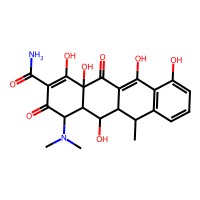
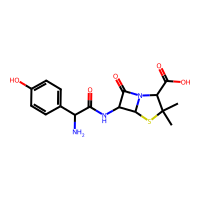

In [5]:
molecules = pd.DataFrame({"smiles": molecule_smiles, "name": molecule_names})
PandasTools.AddMoleculeColumnToFrame(molecules, smilesCol="smiles")
PandasTools.RenderImagesInAllDataFrames(True)
# 显示前 2 个分子
molecules.head(2)

可视化所有分子。


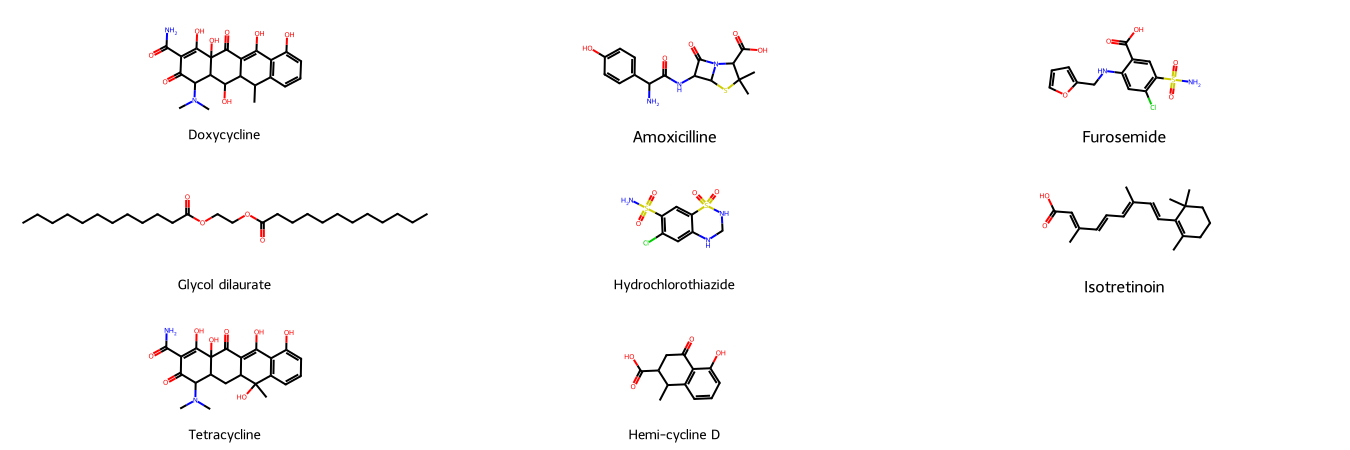

In [6]:
Draw.MolsToGridImage(
    molecules["ROMol"].to_list(),
    molsPerRow=3,
    subImgSize=(450, 150),
    legends=molecules["name"].to_list(),
)

### 计算分子描述符

我们提取并生成 1D 和 2D 分子描述符来比较我们的分子。对于 2D 描述符，我们生成不同类型的指纹，以便后续用于计算分子相似性。


#### 1D 分子描述符：分子量

计算示例结构的分子量。


In [7]:
# 注意：使用 pandas apply 函数对 DataFrame 中的所有 ROMol 对象应用 MolWt 函数
molecules["molecule_weight"] = molecules.ROMol.apply(Descriptors.MolWt)
# 按分子量排序
molecules.sort_values(["molecule_weight"], ascending=False, inplace=True)

我们绘制分子结构及其相似的分子量，以便进行视觉比较：分子量是否是描述分子相似性的可行描述符？


In [8]:
# 仅显示分子名称和分子量
molecules[["smiles", "name", "molecule_weight"]]
# NBVAL_CHECK_OUTPUT

,smiles,name,molecule_weight
0,CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Doxycycline,444.440
6,CC1(C2CC3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Tetracycline,444.440
3,CCCCCCCCCCCC(=O)OCCOC(=O)CCCCCCCCCCC,Glycol dilaurate,426.682
1,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C...,Amoxicilline,365.411
2,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,Furosemide,330.749
5,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C,Isotretinoin,300.442
4,C1NC2=CC(=C(C=C2S(=O)(=O)N1)S(=O)(=O)N)Cl,Hydrochlorothiazide,297.745
7,CC1C(CC(=O)C2=C1C=CC=C2O)C(=O)O,Hemi-cycline D,220.224


我们绘制带有分子量标注的分子。


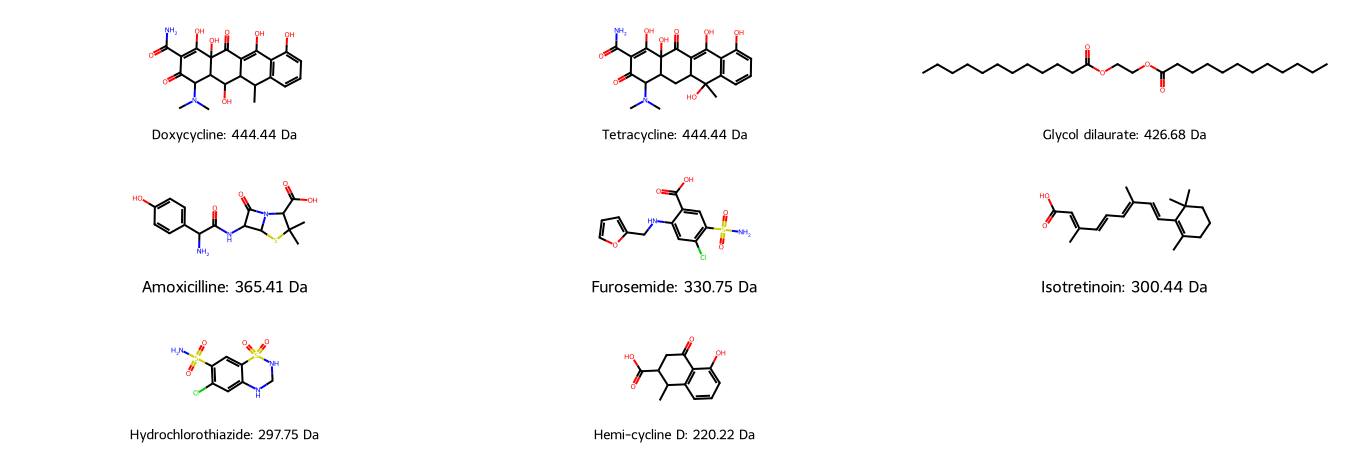

In [9]:
Draw.MolsToGridImage(
    molecules["ROMol"],
    legends=[
        f"{molecule['name']}: {molecule['molecule_weight']:.2f} Da"
        for index, molecule in molecules.iterrows()
    ],
    subImgSize=(450, 150),
    molsPerRow=3,
)

正如我们所看到的，分子量相似的分子可能结构也相似（例如多西环素/四环素），但它们也可能具有相似数量的原子，但排列方式完全不同（例如多西环素/双月桂酸乙二醇酯或氢氯噻嗪/异维A酸）。

为了在结构上区分分子，我们需要更多关于分子结构的详细信息。在使用分子指纹时，我们经常使用 2D 描述符。


#### 2D 分子描述符：MACCS 指纹


__示例分子__：使用我们 `DataFrame` 中的一个示例分子。


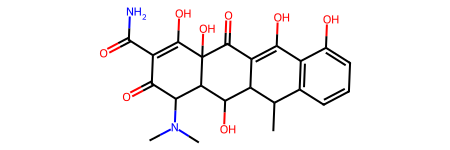

In [10]:
molecule = molecules["ROMol"][0]
molecule

MACCS 指纹可以通过 `rdkit` 方便地生成。


In [11]:
maccs_fp = MACCSkeys.GenMACCSKeys(molecule)

由于显式位向量不易被人类阅读，我们将其进一步转换为位串。


In [12]:
# NBVAL_CHECK_OUTPUT
maccs_fp.ToBitString()

'00000000000000000000000000100000000000000000000000100110000000000010000010101000000011100100110101010100010000101100010000100001000101001001111111101111101011111111110'

__应用于所有分子__：为所有分子添加 MACCS 指纹到 `DataFrame` 中。


In [13]:
molecules["maccs"] = molecules.ROMol.apply(MACCSkeys.GenMACCSKeys)

#### 2D 分子描述符：Morgan 指纹

我们还可以使用 `rdkit` 计算圆形 Morgan 指纹。Morgan 指纹可以计算为 int 向量或 bit 向量。我们指定半径为 2，向量长度为 2048。

__示例分子__：再次使用我们的示例分子。


生成 Morgan 指纹 _作为 int 向量_。


In [14]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
circular_int_fp = fpg.GetCountFingerprint(molecule)
circular_int_fp

In [15]:
# NBVAL_CHECK_OUTPUT
print(f"Print non-zero elements:\n{circular_int_fp.GetNonzeroElements()}")

Print non-zero elements:
{45: 1, 118: 1, 140: 1, 163: 1, 276: 1, 303: 1, 309: 1, 314: 2, 371: 1, 438: 1, 525: 1, 557: 1, 650: 3, 673: 1, 699: 1, 807: 6, 824: 1, 829: 1, 881: 1, 1009: 1, 1019: 5, 1027: 1, 1039: 1, 1057: 3, 1060: 1, 1061: 1, 1070: 1, 1082: 1, 1088: 1, 1119: 1, 1154: 1, 1163: 2, 1171: 1, 1257: 1, 1296: 1, 1309: 1, 1341: 1, 1380: 9, 1389: 1, 1457: 1, 1471: 1, 1487: 1, 1582: 1, 1602: 3, 1607: 1, 1630: 1, 1747: 1, 1750: 2, 1831: 1, 1833: 1, 1857: 1, 1873: 3, 1917: 1, 1932: 1, 2000: 1, 2029: 1}


生成 Morgan 指纹 _作为 bit 向量_。


In [16]:
# 注意该函数以列表作为输入参数
# （即使我们只想传入一个分子）
circular_bit_fp = fpg.GetFingerprint(molecule)
circular_bit_fp

In [17]:
# NBVAL_CHECK_OUTPUT
print(f"Print top 400 fingerprint bits:\n{circular_bit_fp.ToBitString()[:400]}")

Print top 400 fingerprint bits:
0000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000010000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000001000001000010000000000000000000000000000000000000000000000000000000010000000000000000000000000000


__应用于所有分子__：为所有分子添加 Morgan 指纹（作为 bit 向量）到 `DataFrame` 中。


In [18]:
molecules["morgan"] = molecules["ROMol"].map(fpg.GetFingerprint)

### 计算分子相似性

接下来，我们将对两种指纹类型（**MACCS** 和 **Morgan** 指纹）应用两种相似性度量（**Tanimoto** 和 **Dice**）。

__示例分子对__：使用 Tanimoto 相似性比较两个 MACCS 指纹。


In [19]:
# 示例分子
molecule1 = molecules["ROMol"][0]
molecule2 = molecules["ROMol"][1]

# 示例指纹
maccs_fp1 = MACCSkeys.GenMACCSKeys(molecule1)
maccs_fp2 = MACCSkeys.GenMACCSKeys(molecule2)

计算两个不同分子之间的 Tanimoto 系数。


In [20]:
# NBVAL_CHECK_OUTPUT
DataStructs.TanimotoSimilarity(maccs_fp1, maccs_fp2)

0.5909090909090909

计算相同分子之间的 Tanimoto 系数。


In [21]:
# NBVAL_CHECK_OUTPUT
DataStructs.TanimotoSimilarity(maccs_fp1, maccs_fp1)

1.0

接下来，我们想将查询分子与我们的分子列表进行比较。因此，我们使用 `rdkit` 中的 `BulkTanimotoSimilarity` 和 `BulkDiceSimilarity`，它们基于相似性度量计算查询指纹与一系列指纹的相似性。我们将研究所有组合：MACCS 或 Morgan 指纹，结合 Tanimoto 或 Dice 相似性度量。


#### MACCS 指纹：Tanimoto 相似性 和 Dice 相似性


将 MACCS 指纹之间的 Tanimoto 和 Dice 相似性添加到 `DataFrame` 中。


In [22]:
# 定义分子查询词和列表
molecule_query = molecules["maccs"][0]
molecule_list = molecules["maccs"].to_list()
# 计算查询词与列表中各元素的相似度
molecules["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_maccs"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

按 MACCS 指纹的 Tanimoto 相似性对 `DataFrame` 进行排序（仅显示名称和相似性列！）。


In [23]:
preview = molecules.sort_values(["tanimoto_maccs"], ascending=False).reset_index()
preview[["name", "tanimoto_maccs", "dice_maccs"]]
# NBVAL_CHECK_OUTPUT

,name,tanimoto_maccs,dice_maccs
0,Doxycycline,1.000000,1.000000
1,Tetracycline,0.928571,0.962963
2,Amoxicilline,0.590909,0.742857
3,Hemi-cycline D,0.403509,0.575000
4,Furosemide,0.321839,0.486957
5,Hydrochlorothiazide,0.306818,0.469565
6,Isotretinoin,0.288136,0.447368
7,Glycol dilaurate,0.149254,0.259740


__注意__：根据定义，Tanimoto 和 Dice 相似性度量对分子的排序结果相同，但 Dice 相似性的数值更高（参见本教程理论部分的 Tanimoto 和 Dice 公式）。


绘制按 MACCS 指纹 Tanimoto 相似性排序的分子。


In [24]:
def draw_ranked_molecules(molecules, sort_by_column):
    """
    按给定列对分子进行排序并绘制。

    Parameters
    ----------
    molecules : pandas.DataFrame
        分子数据（包含 "ROMol" 和 "name" 列，以及一个排序依据列）。
    sort_by_column : str
        用于排序的列名。

    Returns
    -------
    Draw.MolsToGridImage
        排序后分子的 2D 可视化。
    """

    molecules_sorted = molecules.sort_values([sort_by_column], ascending=False).reset_index()
    return Draw.MolsToGridImage(
        molecules_sorted["ROMol"],
        legends=[
            f"#{index+1} {molecule['name']}, similarity={molecule[sort_by_column]:.2f}"
            for index, molecule in molecules_sorted.iterrows()
        ],
        molsPerRow=3,
        subImgSize=(450, 150),
    )

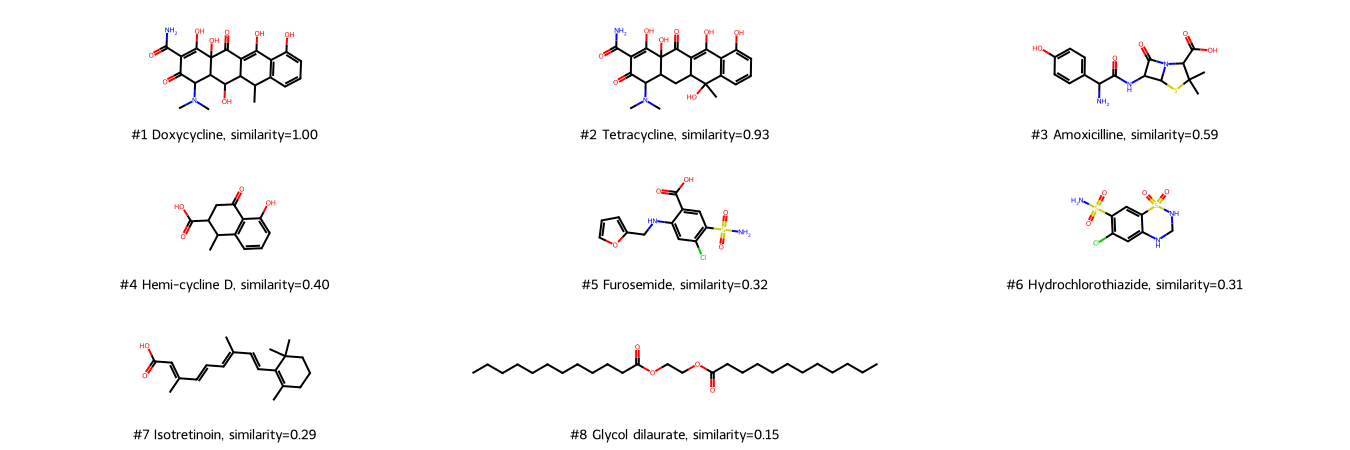

In [25]:
draw_ranked_molecules(molecules, "tanimoto_maccs")

对于 MACCS 指纹，四环素（Tetracycline）是最相似的分子（得分很高），其次是阿莫西林（Amoxicilline）。与 1D 分子量描述符的结果不同，线性分子双月桂酸乙二醇酯（Glycol dilaurate）被识别为不相似分子（排名最后）。


#### Morgan 指纹：Tanimoto 相似性 和 Dice 相似性


将 Morgan 指纹之间的 Tanimoto 和 Dice 相似性添加到 `DataFrame` 中。


In [26]:
# 定义分子查询词和列表
molecule_query = molecules["morgan"][0]
molecule_list = molecules["morgan"].to_list()
# 计算查询词与列表中各元素的相似度
molecules["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_morgan"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

按 Morgan 指纹的 Tanimoto 相似性对 `DataFrame` 进行排序。


In [27]:
preview = molecules.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
preview[["name", "tanimoto_morgan", "dice_morgan", "tanimoto_maccs", "dice_maccs"]]
# NBVAL_CHECK_OUTPUT

,name,tanimoto_morgan,dice_morgan,tanimoto_maccs,dice_maccs
0,Doxycycline,1.000000,1.000000,1.000000,1.000000
1,Tetracycline,0.534247,0.696429,0.928571,0.962963
2,Hemi-cycline D,0.308824,0.471910,0.403509,0.575000
3,Amoxicilline,0.144444,0.252427,0.590909,0.742857
4,Furosemide,0.098901,0.180000,0.321839,0.486957
5,Isotretinoin,0.067416,0.126316,0.288136,0.447368
6,Hydrochlorothiazide,0.058824,0.111111,0.306818,0.469565
7,Glycol dilaurate,0.054795,0.103896,0.149254,0.259740


绘制按 Morgan 指纹 Tanimoto 相似性排序的分子。


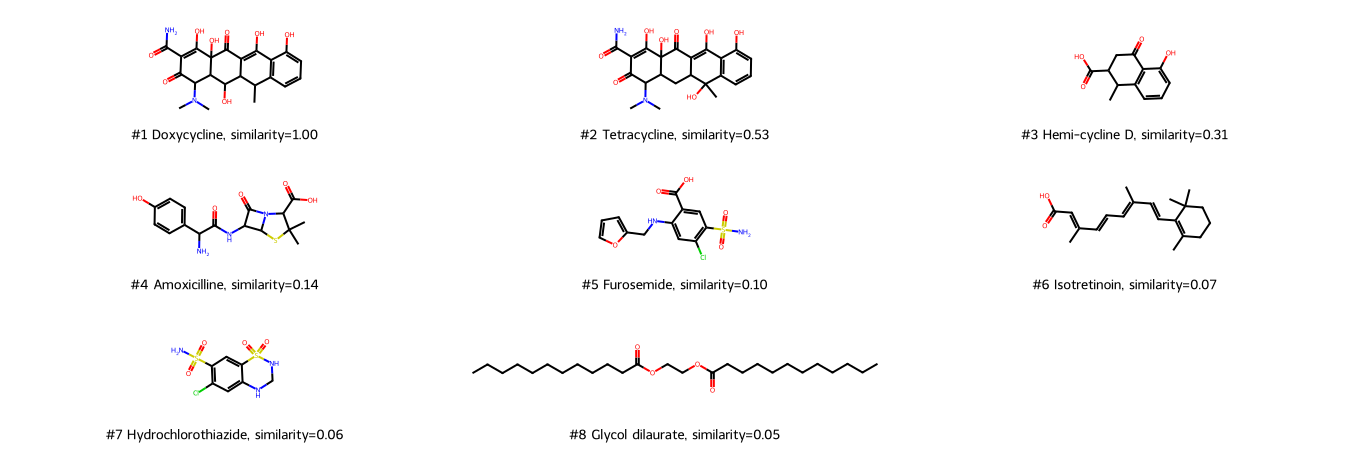

In [28]:
draw_ranked_molecules(molecules, "tanimoto_morgan")

我们比较基于 MACCS 和 Morgan 指纹的 Tanimoto 相似性。因此，我们绘制基于 Morgan 指纹的 Tanimoto 相似性与基于 MACCS 指纹的 Tanimoto 相似性的关系图。


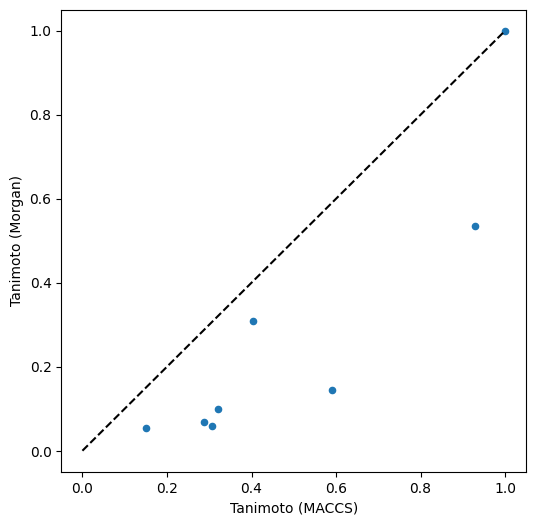

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
molecules.plot("tanimoto_maccs", "tanimoto_morgan", kind="scatter", ax=ax)
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Tanimoto (MACCS)")
ax.set_ylabel("Tanimoto (Morgan)")
fig;

使用不同的指纹（此处为：MACCS 和 Morgan 指纹）会导致不同的相似性值（此处为：Tanimoto 相似性），因此也可能导致不同的分子相似性排序，如此处所示。

Morgan 指纹也识别出四环素（Tetracycline）为最相似分子，其次是甘氨胆酸（Glycocholic acid）和双月桂酸乙二醇酯（Glycol dilaurate）。虽然四环素（Tetracycline）相对这些分子在 MACCS 和 Morgan 指纹的 Tanimoto 相似性之间评分一致，但其他分子则不然，它们的排名在不同指纹之间变化较大。


### 使用相似性搜索进行虚拟筛选

现在我们已经学会了如何计算指纹以及它们之间的相似性，我们可以将这些知识应用于一个查询分子与整个分子数据集的相似性搜索。

我们使用已知的 EGFR 抑制剂吉非替尼（Gefitinib）作为查询分子，使用 **教程 T002** 提供的 ChEMBL 数据库中筛选后的 EGFR 测试分子数据集作为目标数据集。


#### 将查询分子与数据集中的所有分子进行比较

我们从 **教程 T002** 提供的 ChEMBL 数据库中筛选后的 EGFR 测试分子的 *csv* 文件中导入分子。给定一个查询分子（此处为吉非替尼 Gefitinib），我们将对该数据集进行筛选，以找到相似分子。


__数据集__：从包含 SMILES 格式分子的 _csv_ 文件中导入数据。


In [30]:
molecule_dataset = pd.read_csv(
    DATA / "EGFR_compounds_lipinski.csv",
    usecols=["molecule_chembl_id", "smiles", "pIC50"],
)
print(f"Number of molecules in dataset: {len(molecule_dataset)}")
molecule_dataset.head(5)

Number of molecules in dataset: 4635


,molecule_chembl_id,smiles,pIC50
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
3,CHEMBL66031,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910
4,CHEMBL53753,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


__查询分子__：对于查询分子吉非替尼（Gefitinib），从其 SMILES 生成 `ROMol` 对象。


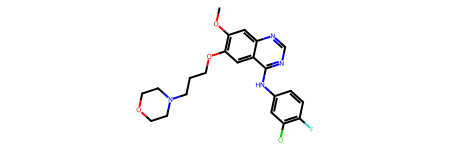

In [31]:
query = Chem.MolFromSmiles("COC1=C(OCCCN2CCOCC2)C=C2C(NC3=CC(Cl)=C(F)C=C3)=NC=NC2=C1")
query

为查询分子生成 MACCS 和 Morgan 指纹。


In [32]:
maccs_fp_query = MACCSkeys.GenMACCSKeys(query)
circular_fp_query = fpg.GetCountFingerprint(query)

为数据集中所有分子生成 MACCS 和 Morgan 指纹。


In [33]:
PandasTools.AddMoleculeColumnToFrame(molecule_dataset, "smiles")
circular_fp_list = molecule_dataset["ROMol"].apply(fpg.GetCountFingerprint).tolist()
maccs_fp_list = molecule_dataset["ROMol"].apply(MACCSkeys.GenMACCSKeys).tolist()

计算查询分子（吉非替尼 Gefitinib）与数据集中所有分子之间的 Tanimoto 相似性（使用 MACCS 和 Morgan 指纹）。


In [34]:
molecule_dataset["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(
    maccs_fp_query, maccs_fp_list
)
molecule_dataset["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(
    circular_fp_query, circular_fp_list
)

为查询分子（吉非替尼 Gefitinib）计算与文件中所有分子的 Dice 相似性（MACCS、Morgan）。


In [35]:
molecule_dataset["dice_maccs"] = DataStructs.BulkDiceSimilarity(maccs_fp_query, maccs_fp_list)
molecule_dataset["dice_morgan"] = DataStructs.BulkDiceSimilarity(
    circular_fp_query, circular_fp_list
)

In [36]:
# NBVAL_CHECK_OUTPUT
molecule_dataset[
    ["smiles", "tanimoto_maccs", "tanimoto_morgan", "dice_maccs", "dice_morgan"]
].head(5)

,smiles,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.409836,0.324786,0.581395,0.490323
1,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.666667,0.445455,0.800000,0.616352
2,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.484375,0.327434,0.652632,0.493333
3,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,0.384615,0.345133,0.555556,0.513158
4,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.428571,0.333333,0.600000,0.500000


,molecule_chembl_id,smiles,pIC50,ROMol,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,,0.409836,0.324786,0.581395,0.490323
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,,0.666667,0.445455,0.800000,0.616352
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,,0.484375,0.327434,0.652632,0.493333

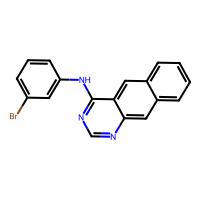
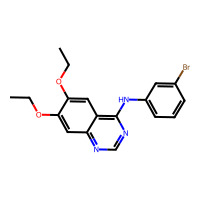
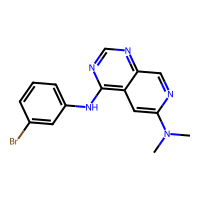

In [37]:
# 显示所有列
molecule_dataset.head(3)

#### 相似性值分布

如理论部分所述，对于同一种指纹（例如 MACCS 指纹），Tanimoto 相似性值低于 Dice 相似性值。此外，比较两种不同的指纹（例如 MACCS 和 Morgan 指纹），其相似性度量生成的相似性值分布也有很大差异。

我们可以查看这些相似性值的分布，以了解相似性计算结果。


首先，我们可以绘制 MACCS 指纹的 Tanimoto 相似性分布。


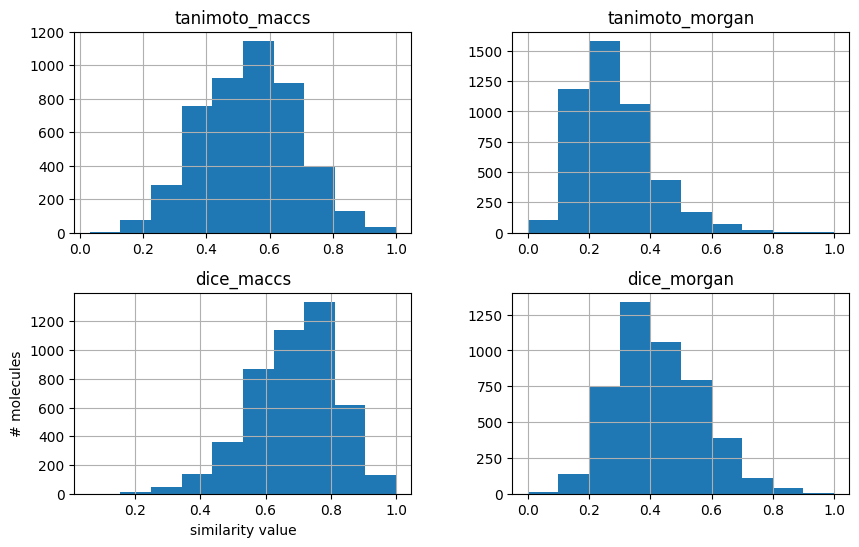

In [38]:
fig, axes = plt.subplots(figsize=(10, 6), nrows=2, ncols=2)
molecule_dataset.hist(["tanimoto_maccs"], ax=axes[0, 0])
molecule_dataset.hist(["tanimoto_morgan"], ax=axes[0, 1])
molecule_dataset.hist(["dice_maccs"], ax=axes[1, 0])
molecule_dataset.hist(["dice_morgan"], ax=axes[1, 1])
axes[1, 0].set_xlabel("similarity value")
axes[1, 0].set_ylabel("# molecules")
fig;

其次，我们可以在这里比较相似性。这次，我们直接比较两种指纹的 Tanimoto 和 Dice 相似性。


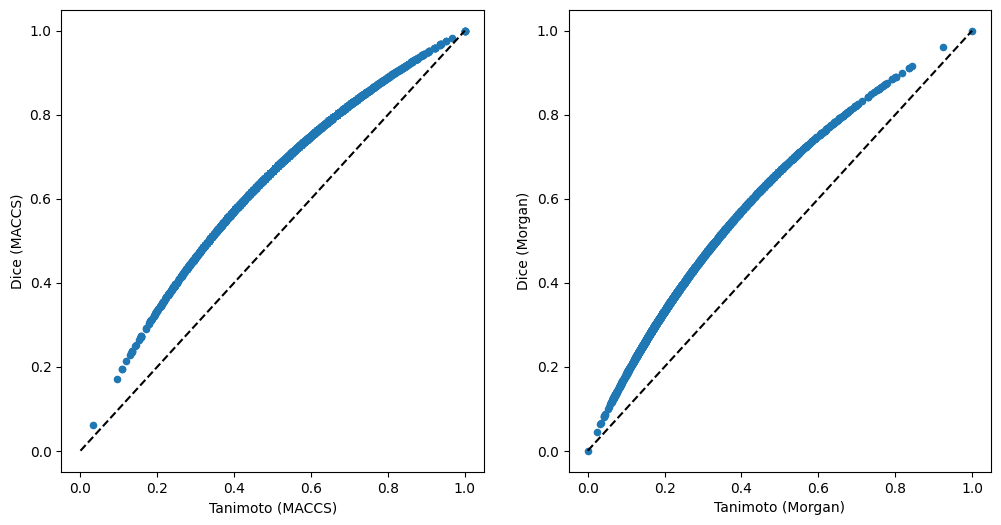

In [39]:
fig, axes = plt.subplots(figsize=(12, 6), nrows=1, ncols=2)

molecule_dataset.plot("tanimoto_maccs", "dice_maccs", kind="scatter", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("Tanimoto (MACCS)")
axes[0].set_ylabel("Dice (MACCS)")

molecule_dataset.plot("tanimoto_morgan", "dice_morgan", kind="scatter", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("Tanimoto (Morgan)")
axes[1].set_ylabel("Dice (Morgan)")

fig;

相似性值的分布对于解释相似性值非常重要，例如，对于 MACCS 或 Morgan 指纹，以及 Tanimoto 或 Dice 相似性，一个 0.6 的值需要不同的解读。


#### 可视化最相似分子


我们通过视觉检查吉非替尼（Gefitinib）的结构，与排名中最相似的分子进行比较，包括来自 ChEMBL 数据库的生物活性信息（pIC50 来源于 **教程 T001**）。


这里，我们按基于 Morgan 指纹的 Tanimoto 相似性对 `DataFrame` 进行排序。


,molecule_chembl_id,smiles,pIC50,ROMol,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
2639,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,6.288193,,1.000000,1.000000,1.000000,1.000000
880,CHEMBL14699,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCOCC1,8.000000,,1.000000,0.923913,1.000000,0.960452
1747,CHEMBL299672,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCC1,7.148742,,0.919355,0.843750,0.957983,0.915254

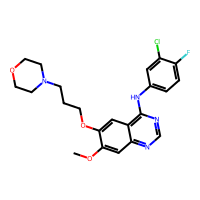
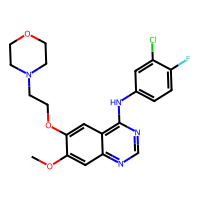
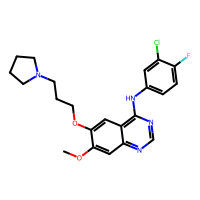

In [40]:
molecule_dataset.sort_values(["tanimoto_morgan"], ascending=False).head(3)

显示查询分子及与其最相似的分子，以及这些分子的生物活性值。


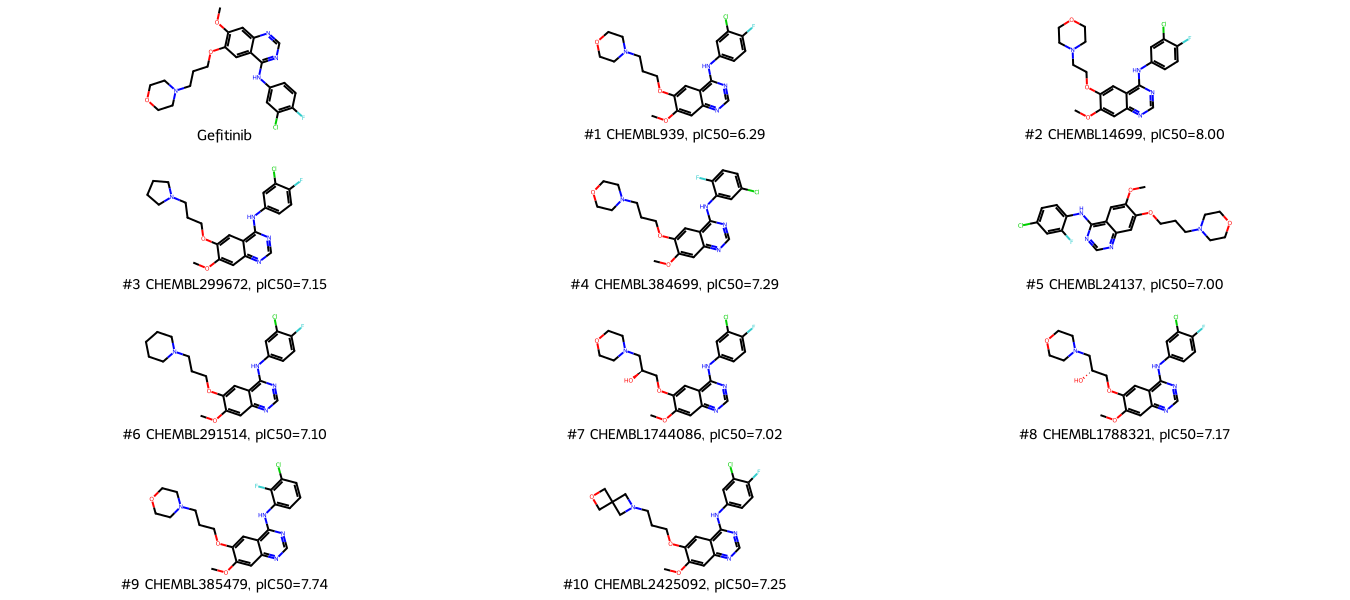

In [41]:
top_n_molecules = 10
top_molecules = molecule_dataset.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
top_molecules = top_molecules[:top_n_molecules]
legends = [
    f"#{index+1} {molecule['molecule_chembl_id']}, pIC50={molecule['pIC50']:.2f}"
    for index, molecule in top_molecules.iterrows()
]
Chem.Draw.MolsToGridImage(
    mols=[query] + top_molecules["ROMol"].tolist(),
    legends=(["Gefitinib"] + legends),
    molsPerRow=3,
    subImgSize=(450, 150),
)

与吉非替尼（Gefitinib）排名最高的分子是我们的数据集中吉非替尼（Gefitinib）的条目（排名 1 和 2），随后是吉非替尼（Gefitinib）的各种变体，例如不同的苯环取代模式。
注意：ChEMBL 包含了吉非替尼（Gefitinib）的完整结构-活性关系分析（作为一种被广泛研究的分子），这也就是为什么我们可以在数据库中为这个查询分子找到如此多相似的条目。


#### 生成富集图

为了验证我们的虚拟筛选并查看检测到的活性分子的比例，我们生成一个富集图。

__富集图__ 显示：

* 来自整个数据集的前 x% 排名分子（x 轴）对比
* 来自整个数据集的前 x% 排名分子中的活性分子比例（y 轴）。


,molecule_chembl_id,smiles,pIC50,ROMol,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,,0.409836,0.324786,0.581395,0.490323
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,,0.666667,0.445455,0.800000,0.616352
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,,0.484375,0.327434,0.652632,0.493333

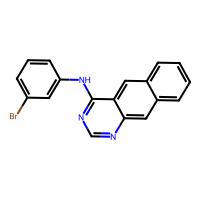
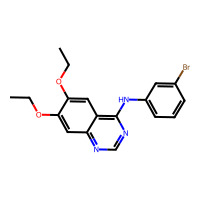
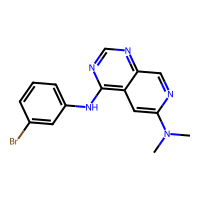

In [42]:
molecule_dataset.head(3)

In [43]:
def get_enrichment_data(molecules, similarity_measure, pic50_cutoff):
    """
    计算富集图的 x 和 y 值：
        x - 已排序数据集中占比（%）
        y - 已识别真实活性分子占比（%）

    Parameters
    ----------
    molecules : pandas.DataFrame
        含有与查询分子相似度值的分子数据。
    similarity_measure : str
        用于对 DataFrame 排序的列名。．
    pic50_cutoff : float
        用于区分活性与非活性分子的 pIC50 截断值。

    Returns
    -------
    pandas.DataFrame
        富集数据：按相似度排序的数据集占比 vs. 已识别真实活性分子占比。
    """

    # Get number of molecules in data set
    molecules_all = len(molecules)

    # Get number of active molecules in data set
    actives_all = sum(molecules["pIC50"] >= pic50_cutoff)

    # 初始化列表，在遍历数据集时用于保存活性和分子计数 dataset
    actives_counter_list = []

    # Initialize counter for actives
    actives_counter = 0

    # Note: Data must be ranked for enrichment plots:
    # Sort molecules by selected similarity measure
    molecules.sort_values([similarity_measure], ascending=False, inplace=True)

    # Iterate over the ranked dataset and check each molecule if active (by checking bioactivity)
    for value in molecules["pIC50"]:
        if value >= pic50_cutoff:
            actives_counter += 1
        actives_counter_list.append(actives_counter)

    # Transform number of molecules into % ranked dataset
    molecules_percentage_list = [i / molecules_all for i in range(1, molecules_all + 1)]

    # Transform number of actives into % true actives identified
    actives_percentage_list = [i / actives_all for i in actives_counter_list]

    # Generate DataFrame with x and y values as well as label
    enrichment = pd.DataFrame(
        {
            "% ranked dataset": molecules_percentage_list,
            "% true actives identified": actives_percentage_list,
        }
    )

    return enrichment

设置用于区分活性和非活性分子的 pIC50 截断值...


In [44]:
pic50_cutoff = 6.3

...并获取 MACCS 和 Morgan 指纹（使用 Tanimoto 相似性）的富集数据。


In [45]:
similarity_measures = ["tanimoto_maccs", "tanimoto_morgan"]
enrichment_data = {
    similarity_measure: get_enrichment_data(molecule_dataset, similarity_measure, pic50_cutoff)
    for similarity_measure in similarity_measures
}

显示富集数据示例。


In [46]:
enrichment_data["tanimoto_maccs"].head()

,% ranked dataset,% true actives identified
0,0.000216,0.00038
1,0.000431,0.00076
2,0.000647,0.00076
3,0.000863,0.00114
4,0.001079,0.00152


将富集数据与最优富集曲线和随机富集曲线一起绘制！


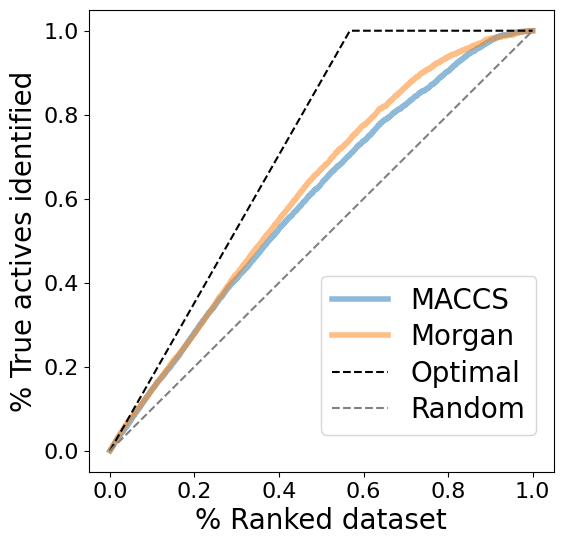

In [47]:
fig, ax = plt.subplots(figsize=(6, 6))

fontsize = 20

# 绘制富集数据
for similarity_measure, enrichment in enrichment_data.items():
    ax = enrichment.plot(
        ax=ax,
        x="% ranked dataset",
        y="% true actives identified",
        label=similarity_measure,
        alpha=0.5,
        linewidth=4,
    )
ax.set_ylabel("% True actives identified", size=fontsize)
ax.set_xlabel("% Ranked dataset", size=fontsize)

# 绘制最优曲线：数据集中活性分子的比例
ratio_actives = sum(molecule_dataset["pIC50"] >= pic50_cutoff) / len(molecule_dataset)
ax.plot(
    [0, ratio_actives, 1],
    [0, 1, 1],
    label="Optimal curve",
    color="black",
    linestyle="--",
)

# 绘制随机曲线
ax.plot([0, 1], [0, 1], label="Random curve", color="grey", linestyle="--")

plt.tick_params(labelsize=16)
plt.legend(
    labels=["MACCS", "Morgan", "Optimal", "Random"],
    loc=(0.5, 0.08),
    fontsize=fontsize,
    labelspacing=0.3,
)

# 保存图表 -- 使用 bbox_inches 包含文本框
plt.savefig(
    DATA / "enrichment_plot.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

富集图显示，基于 Morgan 指纹的指纹比较表现略优于基于 MACCS 指纹的比较。


#### 计算富集因子

（实验）__富集因子（EF）__ 用于通过一个数值而不是图表来评估方法的成功程度。其思路是确定在排序分子的前 x%（例如 5%）中活性分子的比例，由以下辅助函数定义。


In [48]:
def calculate_enrichment_factor(enrichment, ranked_dataset_percentage_cutoff):
    """
    获取给定排序数据集占比的实验富集因子。

    Parameters
    ----------
    enrichment : pd.DataFrame
        富集数据：按相似度排序的数据集占比 vs. 已识别真实活性分子占比。
    ranked_dataset_percentage_cutoff : float or int
        用于计算富集因子的排序数据集占比。

    Returns
    -------
    float
        实验富集因子。
    """

    # 仅保留满足截断值条件的分子
    enrichment = enrichment[
        enrichment["% ranked dataset"] <= ranked_dataset_percentage_cutoff / 100
    ]
    # Get highest percentage of actives and the corresponding percentage of actives
    highest_enrichment = enrichment.iloc[-1]
    enrichment_factor = round(100 * float(highest_enrichment["% true actives identified"]), 1)
    return enrichment_factor

这个辅助函数计算了在排序分子的前 x% 中活性分子的随机富集（__随机富集因子__）。


In [49]:
def calculate_enrichment_factor_random(ranked_dataset_percentage_cutoff):
    """
    获取给定排序数据集占比的随机富集因子。

    Parameters
    ----------
    ranked_dataset_percentage_cutoff : float or int
        用于计算富集因子的排序数据集占比。

    Returns
    -------
    float
        随机富集因子。
    """

    enrichment_factor_random = round(float(ranked_dataset_percentage_cutoff), 1)
    return enrichment_factor_random

这个辅助函数计算了在排序分子的前 x% 中活性分子的最优富集（__最优富集因子__）。随机和最优富集因子是评估某个方法的实验富集因子的参考基准。


In [50]:
def calculate_enrichment_factor_optimal(molecules, ranked_dataset_percentage_cutoff, pic50_cutoff):
    """
    获取给定排序数据集占比的最优随机富集因子。

    Parameters
    ----------
    molecules : pandas.DataFrame
        包含所有分子及 pIC50 值的 DataFrame。
    ranked_dataset_percentage_cutoff : float or int
        用于计算富集因子的排序数据集占比。
    activity_cutoff: float
        用于区分活性与非活性分子的 pIC50 截断值。

    Returns
    -------
    float
        最优富集因子。
    """

    ratio = sum(molecules["pIC50"] >= pic50_cutoff) / len(molecules) * 100
    if ranked_dataset_percentage_cutoff <= ratio:
        enrichment_factor_optimal = round(100 / ratio * ranked_dataset_percentage_cutoff, 1)
    else:
        enrichment_factor_optimal = 100.0
    return enrichment_factor_optimal

现在我们可以计算排序数据集中前 5% 的实验富集因子（EF）...


In [51]:
ranked_dataset_percentage_cutoff = 5

In [52]:
for similarity_measure, enrichment in enrichment_data.items():
    enrichment_factor = calculate_enrichment_factor(enrichment, ranked_dataset_percentage_cutoff)
    print(
        f"Experimental EF for {ranked_dataset_percentage_cutoff}% of ranked dataset ({similarity_measure}): {enrichment_factor}%"
    )
# NBVAL_CHECK_OUTPUT

Experimental EF for 5% of ranked dataset (tanimoto_maccs): 7.2%
Experimental EF for 5% of ranked dataset (tanimoto_morgan): 7.8%


...并将其与随机和最优富集因子进行比较。


In [53]:
enrichment_factor_random = calculate_enrichment_factor_random(ranked_dataset_percentage_cutoff)
print(
    f"Random EF for {ranked_dataset_percentage_cutoff}% of ranked dataset: {enrichment_factor_random}%"
)
enrichment_factor_optimal = calculate_enrichment_factor_optimal(
    molecule_dataset, ranked_dataset_percentage_cutoff, pic50_cutoff
)
print(
    f"Optimal EF for {ranked_dataset_percentage_cutoff}% of ranked dataset: {enrichment_factor_optimal}%"
)
# NBVAL_CHECK_OUTPUT

Random EF for 5% of ranked dataset: 5.0%
Optimal EF for 5% of ranked dataset: 8.8%


## 讨论

我们学会了如何使用指纹和相似性度量来比较查询分子与数据集中的分子，并按相似性对分子进行排序。这种方法是分子虚拟筛选的一个示例。
富集图和富集因子可用于评估虚拟筛选的表现。对我们数据集上这一查询分子的应用表明，Morgan 指纹的表现略优于 MACCS 指纹（但超过某种分子指纹在性能上超过另一种的情况在药物发现项目中并不罕见，这也是为什么我们可以选择最适合特定项目的分子指纹）。


## 测验

* 规避活性悬崖的切入点可能是什么？
* 与彼此相比，MACCS 和 Morgan 指纹各有什么优缺点？
* 如何解释相似性数据框中因使用不同指纹而导致的排序差异？
